# Figure 1C. Attributes of UHVDB (v6 unique viruses)

Plotting logic matches `uhvdb-manuscript-update/figure_1/plot_figure_1bc_r6.py`.


In [1]:
### Load UHVDBv6 metadata (unique viruses only; matches plot_figure_1bc_r6.py)
import polars as pl

META = (
    '/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz'
)

uhvdb_plot_df = (
    pl.read_csv(
        META,
        separator='\t',
        columns=['seq_name', 'source_db', 'body_site', 'db_type', 'checkv_quality', 'seqhash_rep'],
        infer_schema_length=5000,
    )
    .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
)

print(f'Unique viruses (seq_name == seqhash_rep): {uhvdb_plot_df.height:,}')
uhvdb_plot_df.group_by('source_db').len().sort('len', descending=True)

Unique viruses (seq_name == seqhash_rep): 1,155,379


source_db,len
str,u32
"""VIRE""",311723
"""UHGV""",181979
"""SPIRE""",122304
"""OAVGC""",97188
"""NCBIVIRUS""",69521
…,…
"""LOGAN""",12015
"""OVD""",10626
"""VMGC""",5175


source_db: shape: (12, 2)
┌───────────┬────────┐
│ source_db ┆ len    │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ VIRE      ┆ 311723 │
│ UHGV      ┆ 181979 │
│ Other     ┆ 135194 │
│ SPIRE     ┆ 122304 │
│ OAVGC     ┆ 97188  │
│ …         ┆ …      │
│ CNGVC     ┆ 46255  │
│ MAGIC     ┆ 44986  │
│ IMGVR     ┆ 36218  │
│ ENA       ┆ 35211  │
│ MMGE      ┆ 24979  │
└───────────┴────────┘


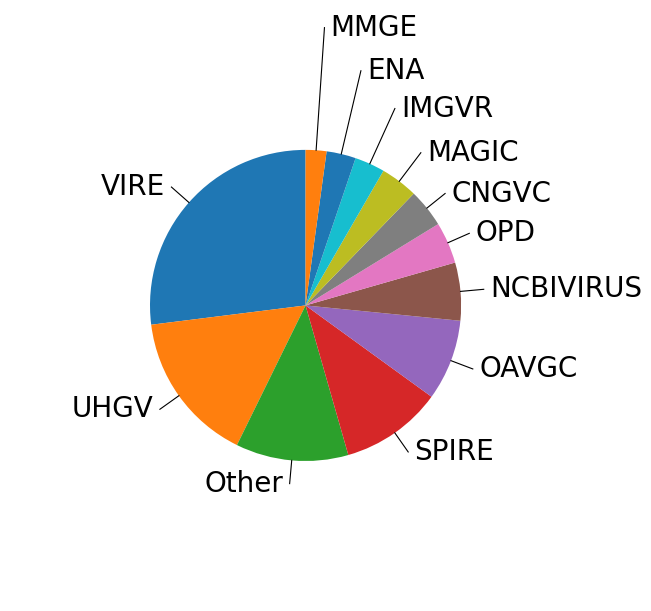

In [2]:
### figure 1c pie chart of source dbs
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

source_db_plot = (
    uhvdb_plot_df
    .with_columns(
        pl.when(
            pl.col('source_db').is_in(
                ['OVD', 'SMGC', 'VMGC', 'LOGAN', 'CHVD', 'CNGVR', 'METAVR', 'CF_METAG', 'MOTUS_DB']
            )
        )
        .then(pl.lit('Other'))
        .otherwise(pl.col('source_db'))
        .alias('source_db')
    )
    .group_by('source_db')
    .len()
    .sort('len', descending=True)
)
print('source_db:', source_db_plot)

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(source_db_plot['len'], startangle=90)

# Short radial connectors; push crowded labels outward so text does not overlap
r0, r_step, min_dy = 1.15, 0.08, 0.22

pts = []
for w, label in zip(wedges, source_db_plot['source_db'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    pts.append({
        'label': label,
        'th': th,
        'x_rim': float(np.cos(th)),
        'y_rim': float(np.sin(th)),
        'side': 'right' if np.cos(th) >= 0 else 'left',
        'r': r0,
    })

for side in ('right', 'left'):
    side_pts = sorted([p for p in pts if p['side'] == side], key=lambda p: p['th'])
    for _ in range(100):
        for p in side_pts:
            p['x'] = p['r'] * p['x_rim']
            p['y'] = p['r'] * p['y_rim']
        moved = False
        for i in range(1, len(side_pts)):
            a, b = side_pts[i - 1], side_pts[i]
            if abs(a['y'] - b['y']) < min_dy and abs(a['x'] - b['x']) < 0.9:
                b['r'] += r_step
                moved = True
        if not moved:
            break

for p in pts:
    ax.plot([p['x_rim'], p['x']], [p['y_rim'], p['y']], color='black', lw=0.8, clip_on=False)
    ax.text(
        p['x'] + (0.04 if p['side'] == 'right' else -0.04),
        p['y'],
        p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=20,
        clip_on=False,
    )

ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.9, 1.9)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


db_type: shape: (2, 2)
┌──────────┬────────┐
│ db_type  ┆ len    │
│ ---      ┆ ---    │
│ str      ┆ u32    │
╞══════════╪════════╡
│ Database ┆ 943531 │
│ Assembly ┆ 211848 │
└──────────┴────────┘


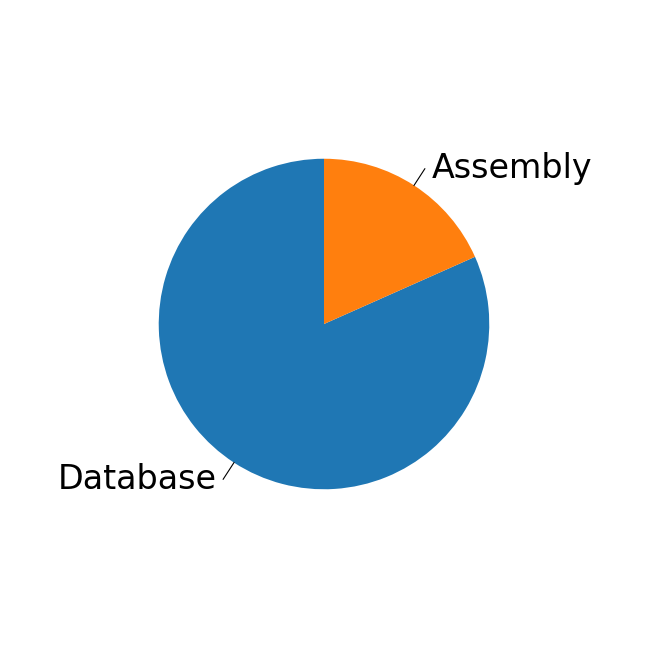

In [3]:
### Figure 1c pie chart of database vs assembly source
import matplotlib.pyplot as plt
import numpy as np

source_type_plot = uhvdb_plot_df.group_by('db_type').len().sort('len', descending=True)
print('db_type:', source_type_plot)

plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(source_type_plot['len'], startangle=90)

r_stub = 1.12
for w, label in zip(wedges, source_type_plot['db_type'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x_rim, y_rim = np.cos(th), np.sin(th)
    x, y = r_stub * x_rim, r_stub * y_rim
    side_right = x_rim >= 0
    ax.plot([x_rim, x], [y_rim, y], color='black', lw=0.8, clip_on=False)
    ax.text(
        x + (0.04 if side_right else -0.04),
        y,
        label,
        ha='left' if side_right else 'right',
        va='center',
        fontsize=24,
        clip_on=False,
    )

ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.9, 1.9)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


body_site: shape: (5, 2)
┌────────────┬────────┐
│ body_site  ┆ len    │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ Gut        ┆ 652093 │
│ Airways    ┆ 333602 │
│ Other      ┆ 143929 │
│ Skin       ┆ 15137  │
│ Urogenital ┆ 10618  │
└────────────┴────────┘


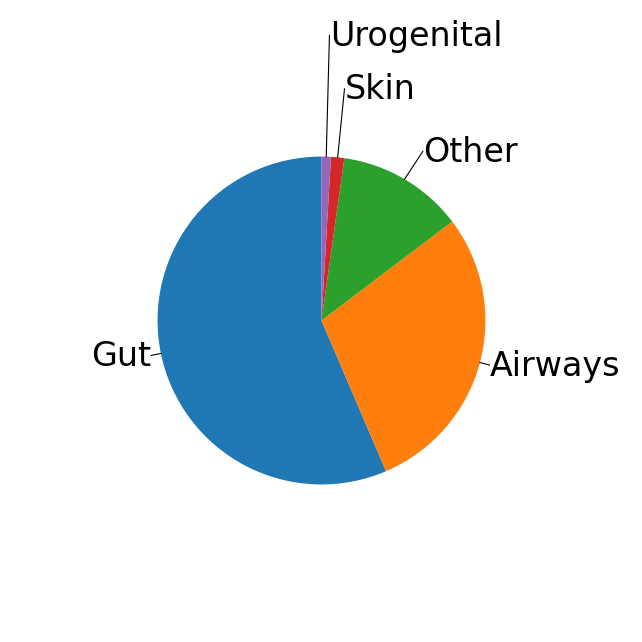

In [4]:
### figure 1c pie chart of body site
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

body_site_plot = (
    uhvdb_plot_df
    .with_columns(
        pl.when(pl.col('body_site') == 'Blood')
        .then(pl.lit('Other'))
        .otherwise(pl.col('body_site'))
        .alias('body_site')
    )
    .group_by('body_site')
    .len()
    .sort('len', descending=True)
)
print('body_site:', body_site_plot)

plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(body_site_plot['len'], startangle=90)

r_line, x_pad = 1.06, 0.003
label_radius_add = {'Urogenital': 0.62, 'Skin': 0.36, 'Other': 0.16}
label_dy = {'Urogenital': 0.06, 'Skin': 0.0, 'Other': -0.02}

pts = []
for w, label in zip(wedges, body_site_plot['body_site'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(th), np.sin(th)
    pts.append({
        'label': label,
        'x': x,
        'y': y,
        'r_end': r_line + label_radius_add.get(label, 0.0),
        'dy': label_dy.get(label, 0.0),
        'side': 'right' if x >= 0 else 'left',
    })

for p in pts:
    x_end = p['r_end'] * p['x']
    y_end = p['r_end'] * p['y'] + p['dy']
    ax.plot([p['x'], x_end], [p['y'], y_end], color='black', lw=0.8)
    x_txt = x_end + x_pad if p['side'] == 'right' else x_end - x_pad
    ax.text(
        x_txt, y_end, p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=24,
    )

ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.9, 1.9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


checkv_quality: shape: (2, 2)
┌────────────────┬────────┐
│ checkv_quality ┆ len    │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ High-quality   ┆ 845619 │
│ Complete       ┆ 309760 │
└────────────────┴────────┘


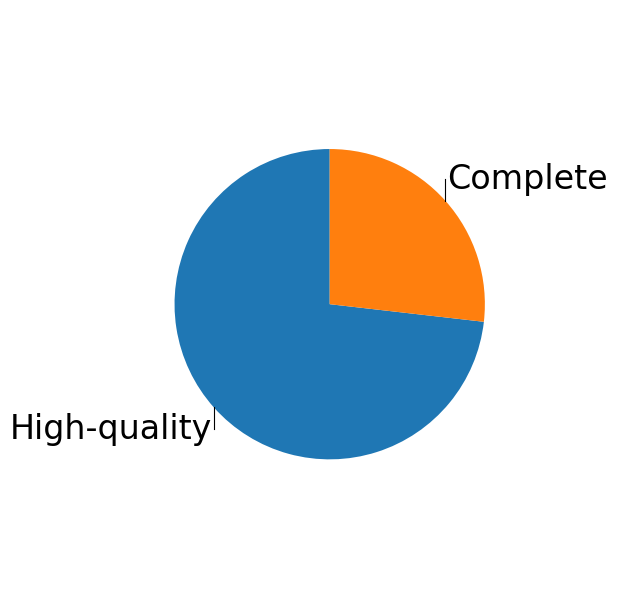

In [5]:
### figure 1c pie chart of CheckV quality
import matplotlib.pyplot as plt
import numpy as np

checkv_quality_plot = uhvdb_plot_df.group_by('checkv_quality').len().sort('len', descending=True)
print('checkv_quality:', checkv_quality_plot)

plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(checkv_quality_plot['len'], startangle=90)

v_len, x_pad = 0.14, 0.01

pts = []
for w, label in zip(wedges, checkv_quality_plot['checkv_quality'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(th), np.sin(th)
    pts.append({
        'label': label,
        'x': x,
        'y': y,
        'y_anchor': y + (v_len if y >= 0 else -v_len),
        'side': 'right' if x >= 0 else 'left',
    })

for p in pts:
    ax.plot([p['x'], p['x']], [p['y'], p['y_anchor']], color='black', lw=0.8)
    x_txt = p['x'] + x_pad if p['side'] == 'right' else p['x'] - x_pad
    ax.text(
        x_txt, p['y_anchor'], p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=24,
    )

ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.9, 1.9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [6]:
# proportion not database and proportion complete
n = uhvdb_plot_df.height
prop_not_database = uhvdb_plot_df.filter(pl.col('db_type') != 'Database').height / n
prop_complete = uhvdb_plot_df.filter(pl.col('checkv_quality') == 'Complete').height / n

print(f'Proportion not from database (Assembly): {prop_not_database:.1%} ({uhvdb_plot_df.filter(pl.col("db_type") != "Database").height:,} / {n:,})')
print(f'Proportion Complete: {prop_complete:.1%} ({uhvdb_plot_df.filter(pl.col("checkv_quality") == "Complete").height:,} / {n:,})')


Proportion not from database (Assembly): 18.3% (211,848 / 1,155,379)
Proportion Complete: 26.8% (309,760 / 1,155,379)
